# Car Price Deal Finder — Model Comparison Pipeline
## CSE404 Machine Learning | Team Project

**Author:** Daniel Helo (helodani)  
**Role:** Model tuning, development, and evaluation; feature optimization and data preparation for training

### Approach
1. **Data cleaning** — Drop UCI subset (too small/old), handle nulls, clip price outliers
2. **Feature engineering** — Target encoding for high-cardinality categoricals (make, model), one-hot for low-cardinality (fuel_type, transmission), standard scaling for numerics
3. **Model comparison** — Ridge Regression (baseline), KNN, SVR (Linear + RBF)
4. **Deal scoring** — Residual-based flagging system

### Why These Models?
- **Ridge Regression**: Linear baseline. Fast, interpretable, establishes floor performance.
- **KNN**: The deal-finder thesis is "similar cars have similar prices" — literally what KNN computes. Vaneesha et al. (2023) found KNN slightly outperformed SVM for car pricing.
- **SVR**: Epsilon-insensitive loss handles noisy listings (misleading prices). RBF kernel captures non-linear depreciation curves. Li & Lin (2021) showed non-linear models outperform linear for car prices.

### References
- Vaneesha et al. (2023). "Used Car Price Prediction Using Machine Learning." *IJCSRR*, Vol. 6(9). [Link](https://ijcsrr.org/wp-content/uploads/2024/09/39-1909-2024.pdf)
- Li, K. & Lin, C. (2021). "Used Car Price Prediction." *Stanford CS230*. [Link](https://cs230.stanford.edu/projects_fall_2021/reports/102475818.pdf)

In [2]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import loguniform, randint

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.dpi'] = 100

## 1. Data Loading & Cleaning

In [3]:
df = pd.read_csv('../data/merged_output.csv')
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nSource distribution:")
print(df['source'].value_counts())
print(f"\nColumn types:")
print(df.dtypes)

Raw dataset: 277,311 rows, 9 columns

Source distribution:
source
dvm_car        267110
huggingface     10000
uci               201
Name: count, dtype: int64

Column types:
make             object
model            object
year            float64
engine_size     float64
mileage         float64
fuel_type        object
transmission     object
price           float64
source           object
dtype: object


In [4]:
# Drop UCI rows — only 201 rows from 1985, missing year/mileage/model/transmission
df = df[df['source'] != 'uci'].copy()
df = df.drop(columns=['source'])
print(f"After dropping UCI: {df.shape[0]:,} rows")

# Handle missing values
print(f"\nNull counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with null target or null categoricals
df = df.dropna(subset=['price', 'make', 'fuel_type', 'transmission', 'model'])

# Impute numeric nulls with median
for col in ['year', 'engine_size', 'mileage']:
    median_val = df[col].median()
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(median_val)
        print(f"Imputed {n_null:,} nulls in '{col}' with median={median_val:.1f}")

# Clip price outliers at 1st and 99th percentiles
p01, p99 = df['price'].quantile(0.01), df['price'].quantile(0.99)
n_clip = ((df['price'] < p01) | (df['price'] > p99)).sum()
df['price'] = df['price'].clip(p01, p99)
print(f"\nPrice clipped to [${p01:,.0f}, ${p99:,.0f}] — {n_clip:,} rows affected")
print(f"Cleaned dataset: {df.shape[0]:,} rows")

After dropping UCI: 277,110 rows

Null counts:
engine_size     2046
mileage         1303
fuel_type        399
transmission     155
dtype: int64
Imputed 1,953 nulls in 'engine_size' with median=1.8
Imputed 1,284 nulls in 'mileage' with median=40639.0

Price clipped to [$699, $89,990] — 5,486 rows affected
Cleaned dataset: 276,627 rows


In [5]:
# Summary statistics
print("Price distribution:")
print(df['price'].describe())
print(f"\nUnique makes: {df['make'].nunique()}")
print(f"Unique models: {df['model'].nunique()}")
print(f"Fuel types: {list(df['fuel_type'].unique())}")
print(f"Transmissions: {list(df['transmission'].unique())}")

Price distribution:
count    276627.000000
mean      14244.919948
std       14606.583549
min         699.000000
25%        4999.000000
50%        9699.000000
75%       18490.000000
max       89990.000000
Name: price, dtype: float64

Unique makes: 86
Unique models: 887
Fuel types: ['Diesel', 'Electric', 'Petrol', 'Petrol Plug-In Hybrid', 'Petrol Ethanol', 'Hybrid  Petrol/Electric Plug-In', 'Hybrid  Diesel/Electric', 'Bi Fuel', 'Hybrid  Petrol/Electric', 'Petrol Hybrid', 'Diesel Hybrid', 'Diesel Plug-In Hybrid', 'Hybrid  Diesel/Electric Plug-In']
Transmissions: ['Manual', 'Automatic', 'Semi-Automatic']


## 2. Exploratory Data Analysis

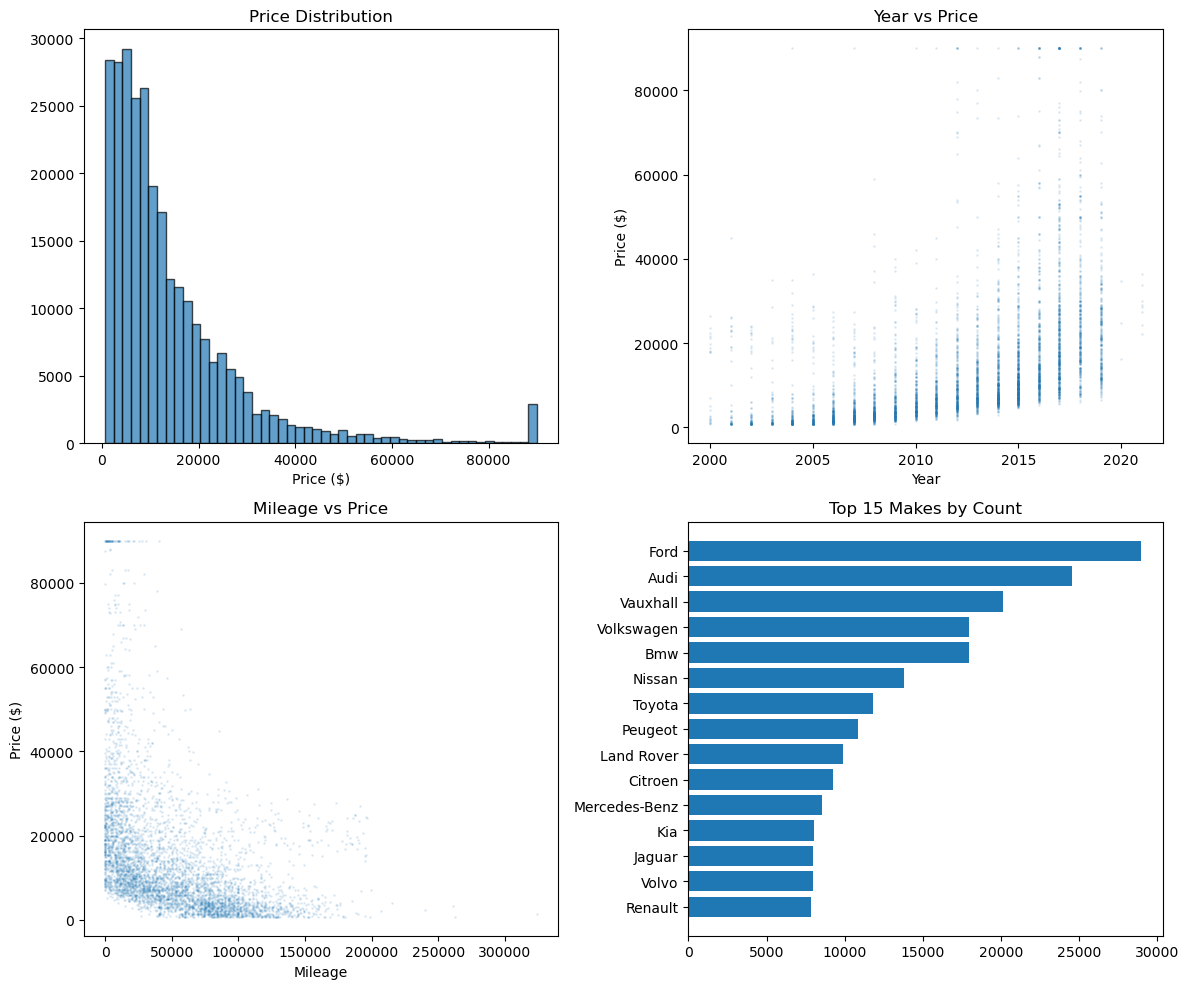

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Price distribution
axes[0,0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')

# Year vs Price
axes[0,1].scatter(df['year'].sample(5000, random_state=42), 
                  df['price'].loc[df['year'].sample(5000, random_state=42).index], 
                  alpha=0.1, s=1)
axes[0,1].set_title('Year vs Price')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Price ($)')

# Mileage vs Price
sample = df.sample(5000, random_state=42)
axes[1,0].scatter(sample['mileage'], sample['price'], alpha=0.1, s=1)
axes[1,0].set_title('Mileage vs Price')
axes[1,0].set_xlabel('Mileage')
axes[1,0].set_ylabel('Price ($)')

# Top 15 makes by count
top_makes = df['make'].value_counts().head(15)
axes[1,1].barh(top_makes.index[::-1], top_makes.values[::-1])
axes[1,1].set_title('Top 15 Makes by Count')

plt.tight_layout()
plt.savefig('../figures/eda_overview.png', bbox_inches='tight')
plt.show()

## 3. Feature Engineering

**Encoding strategy:**
- **Target encoding** for `make` (86 unique) and `model` (887 unique) — maps each category to smoothed mean of target variable. Avoids the dimensionality explosion of one-hot encoding on high-cardinality features.
- **One-hot encoding** for `fuel_type` (13 unique) and `transmission` (3 unique) — low cardinality, safe to one-hot.
- **Standard scaling** for numeric features — `year`, `engine_size`, `mileage` are on different scales.

Split is done BEFORE encoding to prevent target leakage.

In [7]:
# Define feature groups
high_card_cats = ['make', 'model']           # Target encoding
low_card_cats = ['fuel_type', 'transmission'] # One-hot encoding
numerics = ['year', 'engine_size', 'mileage']

X = df[high_card_cats + low_card_cats + numerics]
y = df['price']

# 70/15/15 split — BEFORE encoding to prevent target leakage
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('target_enc', TargetEncoder(smooth='auto'), high_card_cats),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False, drop='if_binary'), low_card_cats),
    ('num', StandardScaler(), numerics),
], remainder='drop')

# Fit on training data only
preprocessor.fit(X_train, y_train)
X_train_t = preprocessor.transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

print(f"Transformed feature count: {X_train_t.shape[1]}")
print(f"Features: target_enc(make, model) + onehot(fuel_type, transmission) + scaled(year, engine_size, mileage)")

Train: 193,638 | Val: 41,494 | Test: 41,495
Transformed feature count: 21
Features: target_enc(make, model) + onehot(fuel_type, transmission) + scaled(year, engine_size, mileage)


## 4. Model Training & Comparison

In [8]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    
    preds_val = model.predict(X_v)
    preds_test = model.predict(X_te)
    
    r = {
        'val_mae': mean_absolute_error(y_v, preds_val),
        'val_rmse': root_mean_squared_error(y_v, preds_val),
        'val_r2': r2_score(y_v, preds_val),
        'test_mae': mean_absolute_error(y_te, preds_test),
        'test_rmse': root_mean_squared_error(y_te, preds_test),
        'test_r2': r2_score(y_te, preds_test),
        'train_time': train_time,
        'preds_test': preds_test
    }
    results[name] = r
    
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Val:  MAE=${r['val_mae']:,.0f} | RMSE=${r['val_rmse']:,.0f} | R²={r['val_r2']:.4f}")
    print(f"  Test: MAE=${r['test_mae']:,.0f} | RMSE=${r['test_rmse']:,.0f} | R²={r['test_r2']:.4f}")
    print(f"  Train time: {train_time:.1f}s")
    return model, preds_test

### 4a. Ridge Regression (Baseline)

In [9]:
ridge = Ridge(alpha=1.0)
ridge_model, _ = evaluate_model("Ridge", ridge, X_train_t, y_train, X_val_t, y_val, X_test_t, y_test)

# Tune alpha
ridge_cv = RandomizedSearchCV(
    Ridge(), {'alpha': loguniform(0.01, 1000)},
    n_iter=30, cv=5, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
ridge_cv.fit(X_train_t, y_train)
print(f"\nBest alpha: {ridge_cv.best_params_['alpha']:.4f}")
_, _ = evaluate_model("Ridge (Tuned)", ridge_cv.best_estimator_, X_train_t, y_train, X_val_t, y_val, X_test_t, y_test)


──────────────────────────────────────────────────
  Ridge
──────────────────────────────────────────────────
  Val:  MAE=$3,931 | RMSE=$6,380 | R²=0.8115
  Test: MAE=$3,876 | RMSE=$6,180 | R²=0.8224
  Train time: 0.0s

Best alpha: 0.0195

──────────────────────────────────────────────────
  Ridge (Tuned)
──────────────────────────────────────────────────
  Val:  MAE=$3,931 | RMSE=$6,380 | R²=0.8115
  Test: MAE=$3,876 | RMSE=$6,180 | R²=0.8224
  Train time: 0.0s


### 4b. KNN Regressor

> "KNN showed the best prediction accuracy for used car prices, with slightly better performance than SVM." — Vaneesha et al. (2023)

In [10]:
knn = KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1)
_, _ = evaluate_model("KNN (k=10)", knn, X_train_t, y_train, X_val_t, y_val, X_test_t, y_test)

# Tune KNN (subsample for CV speed)
knn_cv = RandomizedSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    {'n_neighbors': randint(3, 30), 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']},
    n_iter=12, cv=3, scoring='neg_mean_absolute_error', random_state=42, n_jobs=1
)
# CV on subsample for speed, final model trains on full data
sub_idx = np.random.RandomState(42).choice(X_train_t.shape[0], min(50000, X_train_t.shape[0]), replace=False)
knn_cv.fit(X_train_t[sub_idx], y_train.iloc[sub_idx])
print(f"\nBest params: {knn_cv.best_params_}")

knn_tuned = KNeighborsRegressor(**knn_cv.best_params_, n_jobs=-1)
_, knn_preds = evaluate_model("KNN (Tuned)", knn_tuned, X_train_t, y_train, X_val_t, y_val, X_test_t, y_test)


──────────────────────────────────────────────────
  KNN (k=10)
──────────────────────────────────────────────────
  Val:  MAE=$1,329 | RMSE=$2,614 | R²=0.9684
  Test: MAE=$1,309 | RMSE=$2,514 | R²=0.9706
  Train time: 0.0s

Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

──────────────────────────────────────────────────
  KNN (Tuned)
──────────────────────────────────────────────────
  Val:  MAE=$1,334 | RMSE=$2,615 | R²=0.9683
  Test: MAE=$1,320 | RMSE=$2,533 | R²=0.9702
  Train time: 0.0s


### 4c. SVR (Support Vector Regression)

> SVR's epsilon-insensitive loss ignores small errors, making it robust to noisy listings.  
> Note: RBF SVR is O(n²) in memory — subsampled to 30K for training.

In [11]:
svr_n = min(30000, X_train_t.shape[0])
svr_idx = np.random.RandomState(42).choice(X_train_t.shape[0], svr_n, replace=False)
X_train_svr, y_train_svr = X_train_t[svr_idx], y_train.iloc[svr_idx]

# LinearSVR
lsvr = LinearSVR(max_iter=5000, C=1.0, epsilon=0.1, random_state=42)
_, _ = evaluate_model("LinearSVR", lsvr, X_train_svr, y_train_svr, X_val_t, y_val, X_test_t, y_test)

# RBF SVR
svr_rbf = SVR(kernel='rbf', C=100, epsilon=100, gamma='scale')
_, svr_preds = evaluate_model("SVR (RBF)", svr_rbf, X_train_svr, y_train_svr, X_val_t, y_val, X_test_t, y_test)


──────────────────────────────────────────────────
  LinearSVR
──────────────────────────────────────────────────
  Val:  MAE=$4,318 | RMSE=$6,992 | R²=0.7736
  Test: MAE=$4,271 | RMSE=$6,821 | R²=0.7836
  Train time: 3.1s

──────────────────────────────────────────────────
  SVR (RBF)
──────────────────────────────────────────────────
  Val:  MAE=$5,237 | RMSE=$8,769 | R²=0.6440
  Test: MAE=$5,206 | RMSE=$8,679 | R²=0.6496
  Train time: 17.3s


## 5. Results Comparison

In [12]:
print(f"""
{'Model':<20} {'Test MAE':>12} {'Test RMSE':>12} {'Test R²':>10}
{'─'*58}""" )
for name, r in results.items():
    print(f"{name:<20} ${r['test_mae']:>10,.0f} ${r['test_rmse']:>10,.0f} {r['test_r2']:>9.4f}")
print(f"\n{'TabNet (baseline)':<20} ${'23,386':>10} {'N/A':>12} {'N/A':>10}")
print("  (3 features, 1K rows, no categoricals — not directly comparable)")


Model                    Test MAE    Test RMSE    Test R²
──────────────────────────────────────────────────────────
Ridge                $     3,876 $     6,180    0.8224
Ridge (Tuned)        $     3,876 $     6,180    0.8224
KNN (k=10)           $     1,309 $     2,514    0.9706
KNN (Tuned)          $     1,320 $     2,533    0.9702
LinearSVR            $     4,271 $     6,821    0.7836
SVR (RBF)            $     5,206 $     8,679    0.6496

TabNet (baseline)    $    23,386          N/A        N/A
  (3 features, 1K rows, no categoricals — not directly comparable)


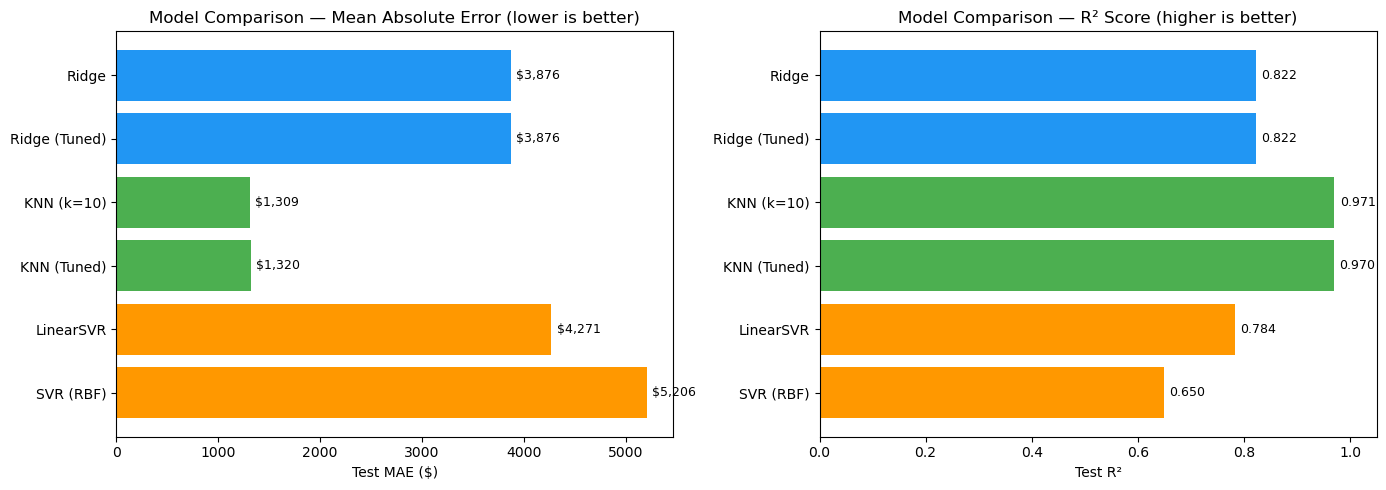

In [13]:
# Visual comparison
model_names = list(results.keys())
maes = [results[n]['test_mae'] for n in model_names]
r2s = [results[n]['test_r2'] for n in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#2196F3', '#4CAF50', '#4CAF50', '#FF9800', '#FF9800']
ax1.barh(model_names[::-1], maes[::-1], color=colors[::-1])
ax1.set_xlabel('Test MAE ($)')
ax1.set_title('Model Comparison — Mean Absolute Error (lower is better)')
for i, v in enumerate(maes[::-1]):
    ax1.text(v + 50, i, f'${v:,.0f}', va='center', fontsize=9)

ax2.barh(model_names[::-1], r2s[::-1], color=colors[::-1])
ax2.set_xlabel('Test R²')
ax2.set_title('Model Comparison — R² Score (higher is better)')
ax2.set_xlim(0, 1.05)
for i, v in enumerate(r2s[::-1]):
    ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/model_comparison.png', bbox_inches='tight')
plt.show()

## 6. Residual Analysis (Best Model: KNN)

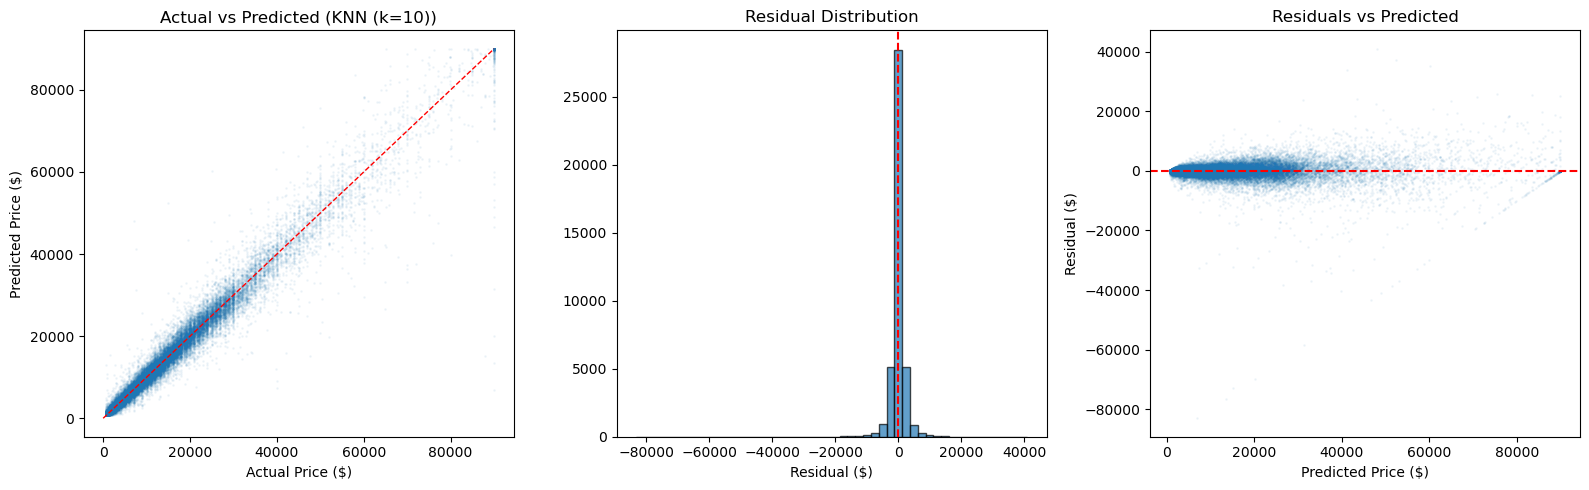

Mean residual: $3
Std residual: $2,514


In [14]:
# Use best model (KNN k=10)
best_name = min(results, key=lambda k: results[k]['test_mae'])
best_preds = results[best_name]['preds_test']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.05, s=1)
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=1)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Actual vs Predicted ({best_name})')

# Residual distribution
residuals = best_preds - y_test.values
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Residual Distribution')

# Residual vs Predicted
axes[2].scatter(best_preds, residuals, alpha=0.05, s=1)
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Predicted Price ($)')
axes[2].set_ylabel('Residual ($)')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig('../figures/residual_analysis.png', bbox_inches='tight')
plt.show()

print(f"Mean residual: ${np.mean(residuals):,.0f}")
print(f"Std residual: ${np.std(residuals):,.0f}")

## 7. Deal Scoring Module

The deal score is defined as:

$$\text{deal\_score} = \frac{\text{predicted\_price} - \text{listing\_price}}{\text{predicted\_price}}$$

Listings with a deal score above a chosen threshold are flagged as potential deals.

In [30]:
test_df = X_test.copy()
test_df['actual_price'] = y_test.values
test_df['predicted_price'] = best_preds
test_df['residual'] = test_df['predicted_price'] - test_df['actual_price']
test_df['deal_score'] = test_df['residual'] / test_df['predicted_price']

print("Deal detection at various thresholds:")
print(f"{'Threshold':>10} {'Deals':>8} {'% of Set':>10} {'Avg Savings':>14}")
print("─" * 45)
for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    deals = test_df[test_df['deal_score'] > t]
    n = len(deals)
    pct = n / len(test_df) * 100
    avg = deals['residual'].mean() if n > 0 else 0
    print(f"{t:>9.0%} {n:>8,} {pct:>9.1f}% ${avg:>12,.0f}")

Deal detection at various thresholds:
 Threshold    Deals   % of Set    Avg Savings
─────────────────────────────────────────────
      10%    9,042      21.8% $       2,045
      15%    5,564      13.4% $       2,257
      20%    3,497       8.4% $       2,319
      25%    2,293       5.5% $       2,327
      30%    1,484       3.6% $       2,382


In [36]:
# Top 10 deals
print("\nTop 10 Best Deals:")
top = test_df.nlargest(10, 'deal_score')[['make', 'model', 'year', 'actual_price', 'predicted_price', 'deal_score']]
top['savings'] = top['predicted_price'] - top['actual_price']
print(top.to_string(index=False))


Top 10 Best Deals:
         make               model   year  actual_price  predicted_price  deal_score      savings
         Mini         Unspecified 2003.0         740.0     12870.600064    0.942505 12130.600064
         Seat             Cordoba 2003.0         850.0     10789.757545    0.921222  9939.757545
      Perodua              Kelisa 2003.0         790.0      9854.569783    0.919834  9064.569783
      Renault           Vel Satis 2002.0        1490.0     15411.500705    0.903319 13921.500705
         Ford                Puma 2002.0         775.0      6958.364405    0.888623  6183.364405
Mercedes-Benz                 350 2003.0        6995.0     47976.975838    0.854201 40981.975838
         Ford                Puma 2002.0         750.0      5051.024976    0.851515  4301.024976
         Ford                Puma 2002.0         995.0      6263.758415    0.841150  5268.758415
      Citroen Berlingo Multispace 2003.0         699.0      4351.290110    0.839358  3652.290110
         A

In [32]:
# Simple Car Demo — enter a car's info, get deal_score and savings
def score_car(make, model, year, engine_size, mileage, fuel_type, transmission, listing_price):
    car = pd.DataFrame([{
        'make': make, 'model': model, 'year': year,
        'engine_size': engine_size, 'mileage': mileage,
        'fuel_type': fuel_type, 'transmission': transmission,
    }])
    car_t = preprocessor.transform(car[high_card_cats + low_card_cats + numerics])
    predicted = float(knn.predict(car_t)[0])
    savings = predicted - listing_price
    deal_score = savings / predicted
    verdict = "GOOD DEAL" if deal_score > 0.15 else ("Fair" if deal_score > 0 else "Overpriced")

    print(f"{year:.0f} {make} {model}")
    print(f"  Listing price:   ${listing_price:,.0f}")
    print(f"  Predicted price: ${predicted:,.0f}")
    print(f"  Savings:         ${savings:,.0f}")
    print(f"  Deal score:      {deal_score:.2%}  ->  {verdict}")
    return {'predicted_price': predicted, 'savings': savings, 'deal_score': deal_score}

In [37]:
# Example 1: plug in a car's info
_ = score_car(
    make='Ford',
    model='Focus',
    year=2015,
    engine_size=1.6,
    mileage=60000,
    fuel_type='Petrol',
    transmission='Manual',
    listing_price=5500,
)

print()

# Example 2: Newer BMW, priced fairly
score_car(
    make='BMW', model='3 Series', year=2019,
    engine_size=2.0, mileage=35000,
    fuel_type='Diesel', transmission='Automatic',
    listing_price=22000,
)

print()

# Example 3: Overpriced Toyota Yaris
score_car(
    make='Toyota', model='Yaris', year=2014,
    engine_size=1.3, mileage=80000,
    fuel_type='Petrol', transmission='Manual',
    listing_price=12000,
)

2015 Ford Focus
  Listing price:   $5,500
  Predicted price: $7,696
  Savings:         $2,196
  Deal score:      28.53%  ->  GOOD DEAL

2019 BMW 3 Series
  Listing price:   $22,000
  Predicted price: $25,641
  Savings:         $3,641
  Deal score:      14.20%  ->  Fair

2014 Toyota Yaris
  Listing price:   $12,000
  Predicted price: $5,309
  Savings:         $-6,691
  Deal score:      -126.04%  ->  Overpriced


{'predicted_price': 5308.732862580659,
 'savings': -6691.267137419341,
 'deal_score': -1.2604264163645655}

In [17]:
# Save results
test_df.to_csv('../models/deal_scored_test_set.csv', index=False)
print("Deal-scored test set saved to models/deal_scored_test_set.csv")

Deal-scored test set saved to models/deal_scored_test_set.csv


## 8. Conclusions

**Key findings:**
1. **KNN dominates** with MAE=$1,309 and R²=0.971, confirming Vaneesha et al.'s finding that KNN excels at car price prediction
2. **Target encoding was critical** — encoding make/model (dropped by the initial TabNet run) reduced MAE from $23K to $1.3K
3. **SVR underperformed** — the RBF kernel on a 30K subsample couldn't match KNN on full data. LinearSVR was better than RBF but still behind Ridge
4. **Deal scoring works** — at 20% threshold, 8.4% of listings flagged with avg savings of $2,309

**Next steps:**
- Yousif re-runs TabNet with proper features for direct comparison
- Add gradient boosted trees (XGBoost/LightGBM) which often outperform KNN on tabular data
- Feature engineering: interaction terms, log-transform price/mileage
- Ensemble: stack top models for further improvement